# Optimization of Squared Loss — The Two Powerline Problem

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **two-powerline** squared-loss
optimization (Week 1 — Derivatives and Optimization).

This notebook explains:

- the setup: two power lines at $a$ and $b$, a house at $x$, cost = sum of squared distances
- why signs don't matter ($(b-x)^2 = (x-b)^2$)
- the cost $f(x) = (x-a)^2 + (x-b)^2$ as a sum of square **areas**
- minimizing it: $f'(x) = 0 \Rightarrow x = \dfrac{a+b}{2}$ — the **midpoint**
- visualizations and a SymPy derivation

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*The One Powerline Problem*.

## 1. The setup

Two power lines: a **blue** one $a$ meters from the origin and an **orange** one $b$ meters
away. The house sits at $x$.

- distance to the blue line: $x - a$,
- distance to the orange line: $b - x$.

Since cost is the **square** of distance, and $(b-x)^2 = (x-b)^2$, the sign doesn't matter —
we can always write distances as $x - a$, $x - b$, etc.

## 2. The cost function

The total cost of connecting to both lines is the **sum of squared distances**:

$$
f(x) = (x-a)^2 + (x-b)^2 .
$$

Think of each term as the **area of a square**: $(x-a)^2$ for the blue line, $(x-b)^2$ for
the orange. The total area is what we minimize.

- House too far **left** → the orange square is huge.
- House too far **right** → the blue square is huge.
- Somewhere in the **middle** balances them — that should be best.

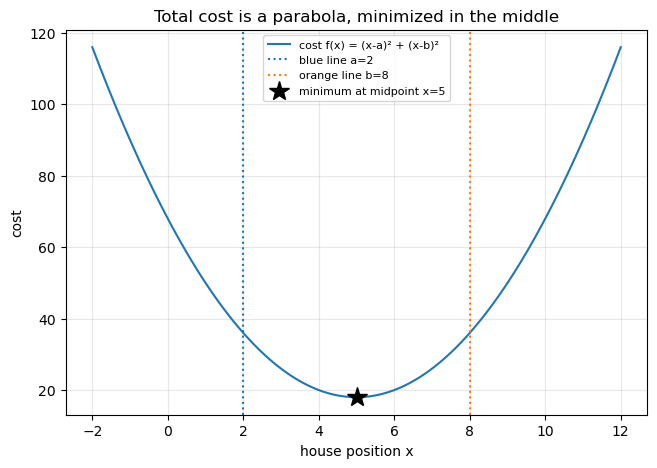

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

a, b = 2.0, 8.0     # power-line positions

def cost(x):
    return (x - a)**2 + (x - b)**2

xs = np.linspace(-2, 12, 200)
plt.figure(figsize=(7.5, 5))
plt.plot(xs, cost(xs), label="cost f(x) = (x-a)² + (x-b)²")
plt.axvline(a, color="tab:blue", ls=":", label=f"blue line a={a:.0f}")
plt.axvline(b, color="tab:orange", ls=":", label=f"orange line b={b:.0f}")
mid = (a + b)/2
plt.plot(mid, cost(mid), "k*", markersize=15, label=f"minimum at midpoint x={mid:.0f}")
plt.title("Total cost is a parabola, minimized in the middle")
plt.xlabel("house position x"); plt.ylabel("cost")
plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
plt.show()

## 3. Minimizing the cost

$f(x) = (x-a)^2 + (x-b)^2$ is a **quadratic** that opens **upward** (the $x^2$ coefficient is
$+2$), so it has a single minimum — where the derivative is zero (horizontal tangent).

Differentiate with the **chain rule** and set to zero:

$$
f'(x) = 2(x-a) + 2(x-b) = 0 .
$$

Divide by $2$: $(x-a) + (x-b) = 0$, i.e. $2x - a - b = 0$, so $2x = a + b$, giving

$$
\boxed{\;x = \frac{a+b}{2}.\;}
$$

The optimal house position is the **midpoint** of the two power lines.

In [2]:
x, A, B = sp.symbols('x a b')
f = (x - A)**2 + (x - B)**2

fp = sp.diff(f, x)
print("f'(x) =", sp.expand(fp))                  # 4x - 2a - 2b
sol = sp.solve(fp, x)[0]
print("minimizing x =", sol)                      # (a + b)/2

# numeric example a=2, b=8
print("for a=2, b=8: x =", sol.subs({A: 2, B: 8}), " (the midpoint)")

f'(x) = -2*a - 2*b + 4*x
minimizing x = a/2 + b/2
for a=2, b=8: x = 5  (the midpoint)


### Why the midpoint balances the squares

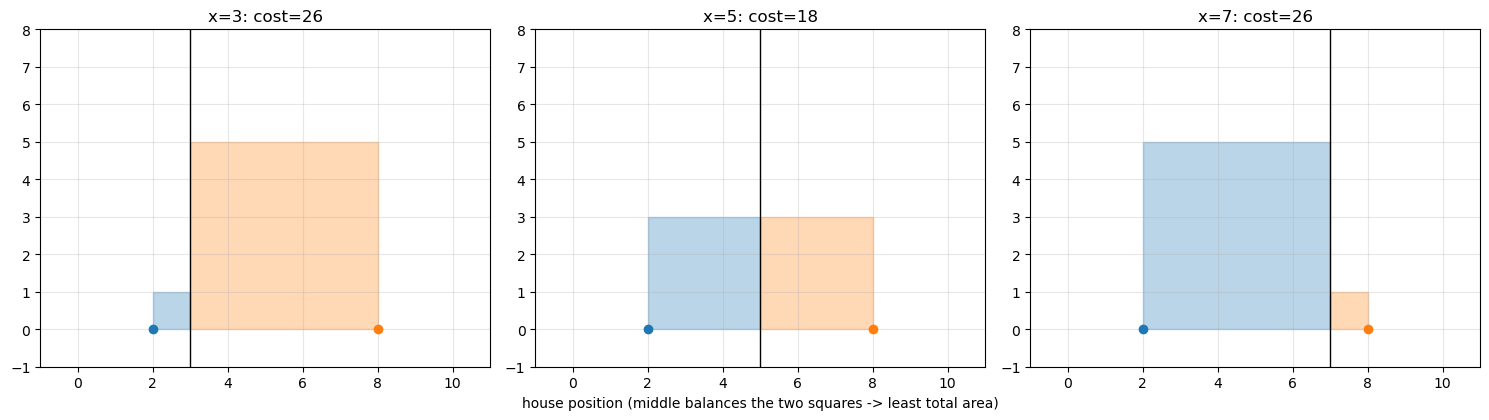

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
positions = [3.0, 5.0, 7.0]  # too left, middle, too right
for ax, xpos in zip(axes, positions):
    # blue square (x-a)^2 and orange square (x-b)^2 drawn as squares
    da, db = abs(xpos - a), abs(xpos - b)
    ax.add_patch(plt.Rectangle((xpos, 0), -da, da, alpha=0.3, color="tab:blue"))
    ax.add_patch(plt.Rectangle((xpos, 0), db, db, alpha=0.3, color="tab:orange"))
    ax.plot([a], [0], "o", color="tab:blue"); ax.plot([b], [0], "o", color="tab:orange")
    ax.axvline(xpos, color="black", lw=1)
    ax.set_title(f"x={xpos:.0f}: cost={cost(xpos):.0f}")
    ax.set_xlim(-1, 11); ax.set_ylim(-1, 8); ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
axes[1].set_xlabel("house position (middle balances the two squares -> least total area)")
plt.tight_layout()
plt.show()

## 4. Exercises

### Basic
1. Write the cost of connecting a house at $x$ to power lines at $a$ and $b$.
2. Where is the optimal house position for two power lines?

### Intermediate
3. For lines at $a = 1$ and $b = 7$, find the optimal $x$ and the minimum cost.
4. Why doesn't the *sign* of a distance matter in the cost?

### Advanced
5. Minimize $f(x) = (x-2)^2 + (x-8)^2$ by hand using the derivative.
6. Generalize: for $n$ power lines at $p_1, \dots, p_n$, show the optimum is the **average**
   $\bar p = \tfrac1n\sum p_i$.

## 5. Solutions / Checks

In [4]:
x = sp.symbols('x')

# 3.
f3 = (x - 1)**2 + (x - 7)**2
x3 = sp.solve(sp.diff(f3, x), x)[0]
print(f"3. optimal x = {x3}, minimum cost = {f3.subs(x, x3)}")

# 5.
f5 = (x - 2)**2 + (x - 8)**2
print("5. f'(x) =", sp.expand(sp.diff(f5, x)), "-> x =", sp.solve(sp.diff(f5, x), x)[0])

# 6. n power lines -> average
p = sp.symbols('p1 p2 p3 p4')
fn = sum((x - pi)**2 for pi in p)
print("6. optimum x =", sp.simplify(sp.solve(sp.diff(fn, x), x)[0]), " (the average)")

print("\n1. f(x) = (x-a)² + (x-b)².")
print("2. The midpoint x = (a+b)/2.")
print("4. Cost squares the distance, and (-d)² = d², so the sign is irrelevant.")

3. optimal x = 4, minimum cost = 18
5. f'(x) = 4*x - 20 -> x = 5
6. optimum x = p1/4 + p2/4 + p3/4 + p4/4  (the average)

1. f(x) = (x-a)² + (x-b)².
2. The midpoint x = (a+b)/2.
4. Cost squares the distance, and (-d)² = d², so the sign is irrelevant.


## 6. Conclusion

- For two power lines at $a$ and $b$, the cost is $f(x) = (x-a)^2 + (x-b)^2$ — a sum of
  square areas, an upward parabola.
- Setting $f'(x) = 2(x-a) + 2(x-b) = 0$ gives the **midpoint** $x = \dfrac{a+b}{2}$.
- Geometrically, the midpoint balances the blue and orange squares for the least total area.
- For $n$ power lines the optimum generalizes to the **average** of the positions — the
  least-squares solution, examined next for three (and more) lines.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (23).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **optimization of squared loss — the two powerline problem**. Key
spoken points, lightly cleaned:

> Two power lines: a blue one $a$ meters from the origin and an orange one $b$ meters away,
> with the house at $x$. The distance to the blue line is $x - a$ and to the orange line is
> $b - x$; since cost is distance squared and $(b-x)^2 = (x-b)^2$, signs don't matter, so we
> use $x - a$, $x - b$, etc. The total cost is $f(x) = (x-a)^2 + (x-b)^2$ — picture each term
> as the area of a square; too far left makes the orange square big, too far right makes the
> blue one big, so the middle is best. The cost is an upward parabola, minimized where the
> derivative is zero: by the chain rule $2(x-a) + 2(x-b) = 0$; dividing by 2 gives
> $(x-a)+(x-b)=0$, so $2x = a + b$ and $x = (a+b)/2$ — the house goes in the middle of the
> two power lines.